In [28]:
import torch
import torchvision
import numpy as np
import pandas as pd
from torchvision import transforms
from tqdm import tqdm
from torch import nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader


### 입력값 설정하기

In [7]:
batch_size = 32     # 배치 크기 설정
feature_size = 128  # input feature 크기 설정

x = torch.rand(batch_size, feature_size)
print(x)

tensor([[4.4141e-01, 3.6848e-01, 9.4290e-01,  ..., 2.6167e-01, 3.3498e-01,
         3.6370e-01],
        [1.0079e-01, 6.8076e-01, 1.1457e-02,  ..., 6.6771e-01, 2.4129e-01,
         6.6078e-01],
        [2.3543e-01, 9.6769e-02, 9.4940e-01,  ..., 3.8723e-01, 6.0881e-01,
         9.1262e-01],
        ...,
        [4.5494e-01, 1.7977e-01, 3.1578e-01,  ..., 1.0442e-01, 7.9619e-01,
         6.3252e-01],
        [8.2294e-01, 4.9916e-01, 2.1643e-01,  ..., 6.3235e-02, 5.7712e-01,
         2.4670e-04],
        [5.0382e-01, 2.2683e-01, 9.4603e-01,  ..., 2.5834e-01, 9.1730e-01,
         7.0637e-01]])


### Fully Connected NN Layer

- 클래스 이름이 Linear인 것은 FC Layer는 Weight와 bias에 대한 선형결합인 것이다. 
- $W \cdot x + b$

In [8]:
in_features = 128
out_features = 64
layer = torch.nn.Linear(in_features = in_features,
                        out_features = out_features,
                        bias = True)

In [9]:
print(layer.weight.shape)
print(layer.bias.shape)

torch.Size([64, 128])
torch.Size([64])


In [10]:
output1 = layer(x)
output2 = x @ layer.weight.T + layer.bias

#print(output1)
#print(output2)}

### Activation Function

In [11]:
act_fn1 = torch.nn.Sigmoid()
act_fn2 = torch.nn.ReLU()
act_fn3 = torch.nn.Tanh()
act_fn4 = torch.nn.Softmax()


out1 = act_fn1(x)
out2 = act_fn2(x)
out3 = act_fn3(x)
out4 = act_fn4(x)

/opt/anaconda3/lib/python3.11/site-packages/torch/nn/modules/module.py:1532: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


### FCNN Model

In [12]:
#First Layer
in_features = 128
out_features = 64
layer1 = torch.nn.Linear(in_features = in_features,
                         out_features = out_features,
                         bias = True)

act_fn1 = torch.nn.Tanh()

In [13]:
#Second Layer
in_features = 64
out_features = 16
layer2 = torch.nn.Linear(in_features = in_features,
                         out_features = out_features,
                         bias = True)

act_fn2 = torch.nn.ReLU()

In [14]:
#Third Layer
in_features = 16
out_features = 1
layer3 = torch.nn.Linear(in_features = in_features,
                         out_features = out_features,
                         bias = True)

act_fn3 = torch.nn.ReLU()

In [15]:
out_1 = act_fn1(layer1(x))
out_2 = act_fn2(layer2(out_1))
out_3 = act_fn3(layer3(out_2))

In [16]:
out_3.shape

torch.Size([32, 1])

### nn.Seqeuntial

nn.Sequential은 여러 개의 Layer를 연속적으로 통과하여 한 번에 forward pass를 할 수 있도록 해준다

In [17]:
## nn.Sequential

model = torch.nn.Sequential(
    #First Layer
    torch.nn.Linear(in_features = 128,
                    out_features = 64,
                    bias = True),

    torch.nn.Tanh(),
    #Second Layer
    torch.nn.Linear(in_features = 64,
                    out_features = 16,
                    bias = True), 

    torch.nn.ReLU(),
    #Third Layer
    torch.nn.Linear(in_features = 16,
                    out_features = 1,
                    bias = True),

    torch.nn.Sigmoid()
)

In [18]:
output = model(x)

In [19]:
output.shape

torch.Size([32, 1])

### nn.Module
nn.Module을 통해서 신경망을 만들 수 있다. 

#### nn.Module의 특징
 - nn.Module을 상속받은 모든 클래스는 신경망 모델이 된다
 - 신경망 모델은 GPU로 이동할 수 있고, 내보내기와 불러오기가 가능하며 복합적 구조를 형성할 수 있다
 - nn.Module은 Parameter를 포함하는데, 이는 학습 중에 최적화되는 가중치와 편향이다

1. init : 신경망 모듈에서 사용되는 모든 모듈을 정의한다 
2. forward : 신경망 모듈에서 사용되는 모든 연산을 정의한다.

In [48]:
class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=784, out_features=128, bias=True),
            torch.nn.Tanh(),
            torch.nn.Linear(in_features=128, out_features=64, bias=True),
            torch.nn.Tanh(),
            torch.nn.Linear(in_features=64, out_features=16, bias=True),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=16, out_features=10, bias=True)  # 수정: out_features=10
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # 입력 데이터 크기 변환
        return self.layers(x)

In [49]:
model

Model(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

#### 두 개의 클래스를 사용한 이유

1. 모듈화 및 재사용성 : NeuralNetwork 클래스는 기본적으로 다양한 신경망을 정의하기 위한 템플릿 역할을 할 수 있다
2. 유연성 : NeuralNetwork 클래스를 사용하면 여러 모델을 상속받아 만들 수 있기 때문에, 코드의 유연성과 확장성이 증가
3. 유지보수성 : 신경망 구조를 변경하거나 추가할 때, 각각의 모델을 개별적으로 정의하면 코드의 중복이 발생할 수 있는데, NeuralNetwork 클래스가 이러한 중복을 줄여준다.


#### Model Class만 사용해도 되나?

된다. 여기서는 단일 모델만을 정의하고 있기 때문에, 굳이 Neural Network Class를 함께 구성할 필요 없다. 다만, 복잡한 모델을 정의하는 경우, 모듈화된 설계로 여러 모델을 효율적으로 관리할 수 있고, 코드의 재사용성과 확장성을 높일 수 있다.

#### Training Loop 만들기

In [4]:
# 데이터 변환 설정
transform = transforms.Compose([
    transforms.ToTensor(),  # 데이터를 Tensor로 변환
    transforms.Normalize((0.5,), (0.5,))  # 데이터 정규화 (평균: 0.5, 표준편차: 0.5)
])

# MNIST 데이터셋 다운로드 및 로드
train_dataset = torchvision.datasets.MNIST(
    root='./data',  # 데이터를 저장할 경로
    train=True,     # 학습 데이터 여부
    download=True,  # 데이터 다운로드
    transform=transform  # 변환 적용
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# DataLoader로 데이터 준비
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)


Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:49<00:00, 199294.71it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 132322.65it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:19<00:00, 83365.28it/s] 


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 1400156.46it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



Epoch 1/100 | Loss: 2.3163: 100%|██████████| 32/32 [00:00<00:00, 429.02it/s]
Epoch 2/100 | Loss: 2.4270: 100%|██████████| 32/32 [00:00<00:00, 1122.17it/s]
Epoch 3/100 | Loss: 2.3389: 100%|██████████| 32/32 [00:00<00:00, 1037.89it/s]
Epoch 4/100 | Loss: 2.2991: 100%|██████████| 32/32 [00:00<00:00, 545.85it/s]
Epoch 5/100 | Loss: 2.3865: 100%|██████████| 32/32 [00:00<00:00, 1043.40it/s]
Epoch 6/100 | Loss: 2.3491: 100%|██████████| 32/32 [00:00<00:00, 888.64it/s]
Epoch 7/100 | Loss: 2.3535: 100%|██████████| 32/32 [00:00<00:00, 463.99it/s]
Epoch 8/100 | Loss: 2.2884: 100%|██████████| 32/32 [00:00<00:00, 931.05it/s]
Epoch 9/100 | Loss: 2.3577: 100%|██████████| 32/32 [00:00<00:00, 1212.27it/s]
Epoch 10/100 | Loss: 2.3568: 100%|██████████| 32/32 [00:00<00:00, 508.56it/s]
Epoch 11/100 | Loss: 2.3979: 100%|██████████| 32/32 [00:00<00:00, 1161.86it/s]
Epoch 12/100 | Loss: 2.2990: 100%|██████████| 32/32 [00:00<00:00, 1104.45it/s]
Epoch 13/100 | Loss: 2.2996: 100%|██████████| 32/32 [00:00<00:00, 4

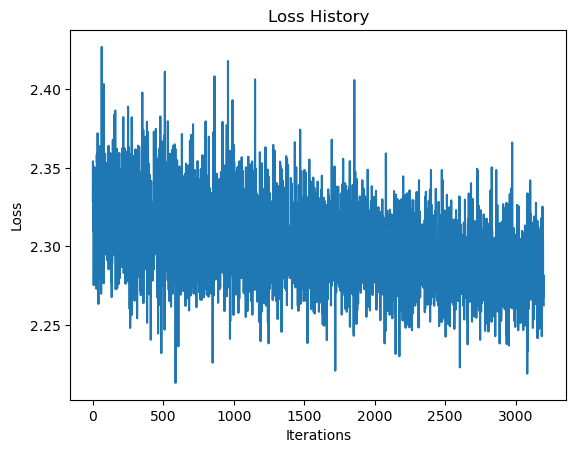

In [51]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(
        torch.randn(1000, 1, 28, 28),  # 1000개의 더미 이미지
        torch.randint(0, 10, (1000,))  # 1000개의 더미 레이블 (0~9)
    ),
    batch_size=batch_size,
    shuffle=True
)

# 모델, 손실 함수, 옵티마이저 정의
model = Model()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

# 학습 루프
loss_history = []
epochs = 100

for epoch in range(epochs):
    tbar = tqdm(train_loader)
    for batch, label in tbar:
        batch = batch.view(batch.size(0), -1)  # 입력 데이터 변환 (batch_size, 784)
        
        # Forward
        pred = model(batch)
        loss = loss_fn(pred, label)
        
        # Backward
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        # Progress 업데이트
        tbar.set_description(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")
        loss_history.append(loss.item())

# 손실 시각화
plt.figure()
plt.plot(loss_history)
plt.title("Loss History")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()